# Chapter 5 - Model Evaluation and Improvement

**Book:** Introduction to Machine Learning with Python  
**Authors:** Andreas C. Müller & Sarah Guido

Chapter ini membahas bagaimana mengevaluasi performa model machine
learning dan bagaimana meningkatkan model menggunakan cross-validation,
grid search, random search, dan evaluasi model yang tepat.

## 1. Chapter Overview

Model machine learning tidak cukup hanya dilatih. Kita juga perlu
mengetahui apakah model dapat bekerja dengan baik pada data baru.

Chapter ini membahas:

1. Cross-Validation
2. Stratified K-Fold Cross-Validation
3. Leave-One-Out Cross-Validation
4. Shuffle-Split Cross-Validation
5. Grid Search
6. Randomized Search
7. Evaluation Metrics
8. Confusion Matrix
9. Precision, Recall, dan F1-Score
10. ROC Curve dan AUC
11. Regression Metrics
12. Imbalanced Datasets

## 2. Train-Test Split

Train-test split membagi dataset menjadi dua bagian:

- Training set → digunakan untuk melatih model.
- Test set → digunakan untuk mengevaluasi model.

Test set sebaiknya tidak digunakan selama proses training.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

print("Training accuracy:", model.score(X_train, y_train))
print("Testing accuracy :", model.score(X_test, y_test))

Training accuracy: 0.9577464788732394
Testing accuracy : 0.958041958041958


## 3. Cross-Validation

Cross-validation digunakan untuk memperoleh evaluasi model
yang lebih stabil.

Pada K-Fold Cross-Validation, data dibagi menjadi beberapa bagian.

Contoh 5-fold:

Fold 1 → Testing
Fold 2-5 → Training

Proses tersebut diulang sampai semua fold pernah digunakan
sebagai data testing.

In [2]:
from sklearn.model_selection import cross_val_score

model = LogisticRegression(max_iter=5000)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print("Scores:", scores)
print("Mean score:", scores.mean())

Scores: [0.93859649 0.94736842 0.98245614 0.92982456 0.95575221]
Mean score: 0.9507995652848935


## 4. Stratified K-Fold Cross-Validation

Untuk classification, Stratified K-Fold menjaga proporsi kelas
pada setiap fold.

Contohnya jika dataset memiliki:

80% kelas 0
20% kelas 1

Maka setiap fold akan berusaha mempertahankan proporsi tersebut.

In [3]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv
)

print("Scores:", scores)
print("Mean:", scores.mean())

Scores: [0.96491228 0.92105263 0.96491228 0.94736842 0.97345133]
Mean: 0.9543393882937432


## 5. Leave-One-Out Cross-Validation

Leave-One-Out menggunakan satu data sebagai testing
dan seluruh data lainnya sebagai training.

Proses dilakukan sebanyak jumlah data.

Metode ini dapat menghasilkan evaluasi yang detail,
tetapi membutuhkan proses komputasi lebih banyak.

In [4]:
from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()

# Gunakan subset agar proses tetap ringan
X_small = X[:100]
y_small = y[:100]

scores = cross_val_score(
    model,
    X_small,
    y_small,
    cv=loo
)

print("Jumlah evaluasi:", len(scores))
print("Mean accuracy:", scores.mean())

Jumlah evaluasi: 100
Mean accuracy: 0.93


## 6. Shuffle-Split Cross-Validation

Shuffle-Split melakukan pengacakan data kemudian membuat
training dan testing set beberapa kali.

Ukuran training dan testing dapat ditentukan secara langsung.

In [5]:
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(
    n_splits=5,
    test_size=0.25,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv
)

print("Scores:", scores)
print("Mean:", scores.mean())

Scores: [0.96503497 0.97202797 0.97902098 0.95104895 0.94405594]
Mean: 0.9622377622377624


## 7. Grid Search

Model memiliki hyperparameter yang dapat diatur.

Contohnya pada Logistic Regression:
- C

Grid Search mencoba semua kombinasi parameter
yang telah ditentukan.

Tujuannya mencari kombinasi parameter dengan performa
cross-validation yang baik.

In [6]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5
)

grid_search.fit(X_train, y_train)

print("Best parameter:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)
print("Test score:", grid_search.score(X_test, y_test))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best parameter: {'C': 100}
Best CV score: 0.9623803009575924
Test score: 0.965034965034965


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 8. Randomized Search

Randomized Search memilih kombinasi hyperparameter
secara acak dari distribusi tertentu.

Keuntungannya adalah dapat lebih efisien ketika jumlah
kombinasi hyperparameter sangat banyak.

In [7]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_grid = {
    "C": np.logspace(-3, 3, 20)
}

random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=5000),
    param_distributions=param_grid,
    n_iter=5,
    cv=5,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best parameter:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best parameter: {'C': np.float64(54.555947811685144)}
Best CV score: 0.9600547195622436


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 9. Evaluation Metrics

Accuracy bukan satu-satunya metrik untuk mengevaluasi model.

Untuk classification kita dapat menggunakan:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Pemilihan metrik harus disesuaikan dengan tujuan permasalahan.

## 10. Confusion Matrix

Confusion matrix menunjukkan jumlah:

- True Positive (TP)
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)

Matrix ini membantu memahami kesalahan yang dibuat model.

In [8]:
from sklearn.metrics import confusion_matrix

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[49  4]
 [ 1 89]]


## 11. Precision, Recall, dan F1-Score

### Precision
Mengukur seberapa banyak prediksi positif yang benar.

### Recall
Mengukur seberapa banyak data positif yang berhasil ditemukan.

### F1-Score
Merupakan kombinasi antara precision dan recall.

In [9]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.92      0.95        53
           1       0.96      0.99      0.97        90

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



## 12. ROC Curve and AUC

ROC Curve menunjukkan hubungan antara:

- True Positive Rate
- False Positive Rate

AUC (Area Under the Curve) merangkum performa ROC
menjadi satu nilai.

Semakin besar AUC, semakin baik kemampuan model
dalam membedakan kelas pada data evaluasi.

ROC-AUC: 0.9966457023060797


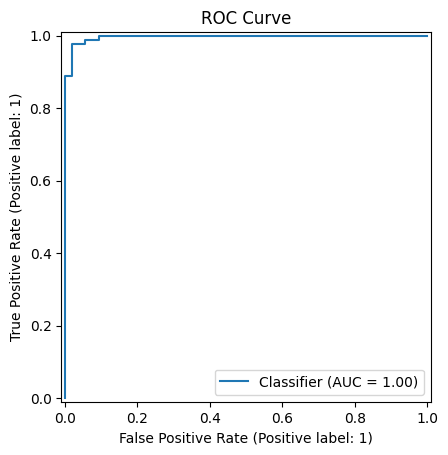

In [10]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_probability = best_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", auc)

RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title("ROC Curve")
plt.show()

## 13. Precision-Recall Curve

Precision-Recall Curve menunjukkan hubungan antara
precision dan recall pada berbagai threshold.

Kurva ini sangat berguna ketika dataset memiliki
ketidakseimbangan kelas.

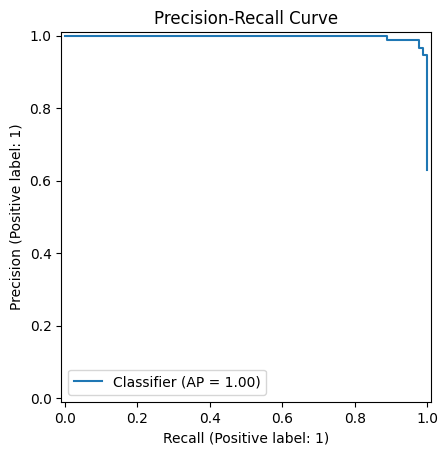

In [11]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title("Precision-Recall Curve")
plt.show()

## 14. Regression Metrics

Untuk regression, metrik yang umum digunakan antara lain:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score

MAE menunjukkan rata-rata besar kesalahan absolut.

MSE memberikan penalti lebih besar terhadap kesalahan yang besar.

R² menunjukkan seberapa baik model menjelaskan variasi target.

In [12]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

diabetes = load_diabetes()

X_reg = diabetes.data
y_reg = diabetes.target

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=42
)

reg_model = Ridge()

reg_model.fit(
    X_train_reg,
    y_train_reg
)

y_pred_reg = reg_model.predict(
    X_test_reg
)

mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

mse = mean_squared_error(
    y_test_reg,
    y_pred_reg
)

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print("MAE :", mae)
print("MSE :", mse)
print("R²  :", r2)

MAE : 45.91343863373228
MSE : 3105.4721464484733
R²  : 0.43840029731424435


## 15. Imbalanced Datasets

Imbalanced dataset terjadi ketika jumlah data antar kelas
sangat berbeda.

Contoh:

Class 0 → 95%
Class 1 → 5%

Dalam kondisi seperti ini, accuracy dapat memberikan
gambaran yang kurang lengkap.

Precision, recall, F1-score, dan confusion matrix dapat
memberikan informasi tambahan mengenai performa model.

In [13]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.965034965034965

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95        53
           1       0.96      0.99      0.97        90

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



## 16. Comparing Evaluation Methods

| Metode | Kegunaan |
|---|---|
| Train-Test Split | Evaluasi sederhana |
| Cross-Validation | Evaluasi lebih stabil |
| Grid Search | Mencari kombinasi parameter |
| Randomized Search | Pencarian parameter lebih efisien |
| Accuracy | Proporsi prediksi benar |
| Precision | Ketepatan prediksi positif |
| Recall | Kemampuan menemukan kelas positif |
| F1-Score | Gabungan precision dan recall |
| ROC-AUC | Evaluasi kemampuan membedakan kelas |
| MAE | Besar kesalahan absolut |
| MSE | Penalti lebih besar untuk error besar |
| R² | Proporsi variasi yang dijelaskan model |

## 17. Results and Analysis

Evaluasi model tidak sebaiknya hanya menggunakan satu train-test split.

Cross-validation memberikan beberapa hasil evaluasi sehingga
performa model dapat dinilai dengan lebih stabil.

Grid Search dan Randomized Search dapat digunakan untuk mencari
hyperparameter yang sesuai.

Untuk classification, accuracy dapat dilengkapi dengan precision,
recall, F1-score, confusion matrix, dan ROC-AUC.

Untuk regression, MAE, MSE, dan R² dapat digunakan sesuai kebutuhan.

## 18. Chapter Summary

Chapter ini membahas cara mengevaluasi dan meningkatkan model.

Hal-hal penting:

- Train-test split digunakan untuk memisahkan data training dan testing.
- Cross-validation memberikan evaluasi yang lebih stabil.
- Stratified K-Fold menjaga proporsi kelas.
- Leave-One-Out menggunakan satu data sebagai test pada setiap iterasi.
- Shuffle-Split melakukan pembagian data secara acak berulang.
- Grid Search mencoba kombinasi hyperparameter.
- Randomized Search mencoba kombinasi parameter secara acak.
- Classification dapat dievaluasi menggunakan berbagai metrik.
- Regression menggunakan metrik seperti MAE, MSE, dan R².
- Dataset tidak seimbang membutuhkan perhatian terhadap pemilihan metrik.